# Laboratorio 5: Frecuencias, n-gramas, nube de palabras y modelo preliminar

Se utiliza `train_clean.csv`, generado en el notebook anterior, que ya contiene la columna
`clean_text` con el texto preprocesado.

**Este notebook se encarga de:**
1. Calcular la **frecuencia de palabras** (unigramas) para cada clase (`target = 0` y `target = 1`).
2. Generar la **nube de palabras** para cada clase.
3. Analizar **bigramas y trigramas** para evaluar si aportan contexto útil.
4. Discutir qué palabras tienen presencia en ambas categorías (poco discriminantes) frente a las que
   son casi exclusivas de una (muy discriminantes).
5. Entrenar y comparar **modelos de clasificación preliminares** (baseline) usando `scikit-learn`.


In [4]:
import warnings
warnings.filterwarnings("ignore")

from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Carga del dataset preprocesado

Cargamos `train_clean.csv` y separamos los tweets en dos subconjuntos
según `target`, que usaremos durante todo el análisis de frecuencias.


In [5]:
df = pd.read_csv("./data/train_clean.csv")
df["clean_text"] = df["clean_text"].fillna("")  # por si algún texto quedó vacío tras la limpieza

df_desastre = df[df["target"] == 1]
df_no_desastre = df[df["target"] == 0]

print(f"Tweets 'desastre real' (1)  : {len(df_desastre):,}")
print(f"Tweets 'no desastre'   (0)  : {len(df_no_desastre):,}")
df.head(3)


Tweets 'desastre real' (1)  : 3,271
Tweets 'no desastre'   (0)  : 4,342


,id,keyword,location,text,clean_text,n_caracteres,n_palabras,clean_n_palabras,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deeds reason earthquake may allah forgive us,69,13,7,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,38,7,7,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,residents asked shelter place notified officers evacuation shelter place orders expected,133,22,11,1


## 2. Frecuencia de palabras (unigramas) por clase

Contamos cuántas veces aparece cada palabra en el texto limpio, por separado para cada clase.
`CountVectorizer` de scikit-learn es útil aquí porque ya nos entrega la matriz de conteos y el
vocabulario ordenado, pero para top-N simples también usamos `Counter` sobre los tokens, que es más
directo de interpretar.


In [6]:
def top_palabras(textos, n=20):
    contador = Counter()
    for t in textos:
        contador.update(t.split())
    return contador.most_common(n)


top_desastre = top_palabras(df_desastre["clean_text"], n=20)
top_no_desastre = top_palabras(df_no_desastre["clean_text"], n=20)

tabla_frecuencias = pd.DataFrame({
    "palabra_desastre": [p for p, _ in top_desastre],
    "freq_desastre": [f for _, f in top_desastre],
    "palabra_no_desastre": [p for p, _ in top_no_desastre],
    "freq_no_desastre": [f for _, f in top_no_desastre],
})
tabla_frecuencias


,palabra_desastre,freq_desastre,palabra_no_desastre,freq_no_desastre
0,fire,182,like,254
1,news,137,new,171
2,disaster,121,get,163
3,via,121,one,133
4,california,115,body,115
5,suicide,112,would,101
6,police,109,via,99
7,people,105,video,96
8,killed,95,people,94
9,like,94,love,91


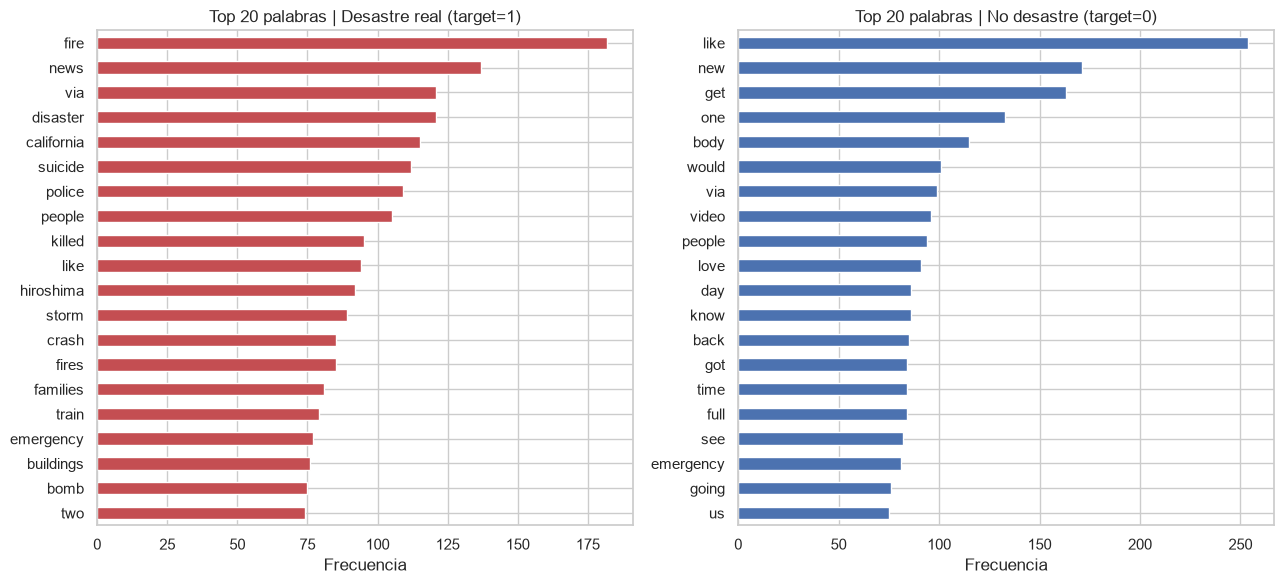

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

pd.Series(dict(top_desastre)).sort_values().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("Top 20 palabras | Desastre real (target=1)")
axes[0].set_xlabel("Frecuencia")

pd.Series(dict(top_no_desastre)).sort_values().plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Top 20 palabras | No desastre (target=0)")
axes[1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()


**Interpretación:** en la clase *desastre real* dominan palabras muy asociadas a eventos
concretos (`fire`, `news`, `disaster`, `killed`, `california`, `storm`, `police`, `suicide`,
`flood`...), mientras que en la clase *no desastre* aparecen palabras de uso coloquial/figurado en
Twitter (`like`, `im`, `get`, `new`, `body`, `via`) que se usan tanto en contextos literales como
metafóricos ("this concert was a disaster"). Esto confirma la intuición del enunciado: hay palabras
con alto poder discriminante (`fire`, `suicide`, `flood`, `killed`, `disaster`, `california`) que
muy probablemente aportarán al modelo, y otras muy frecuentes en ambas clases (ver sección 4) que
aportarán poco por sí solas.


## 3. Nube de palabras por clase

La nube de palabras es una forma rápida y visual de detectar los términos más frecuentes: el tamaño
de cada palabra es proporcional a su frecuencia en el corpus.


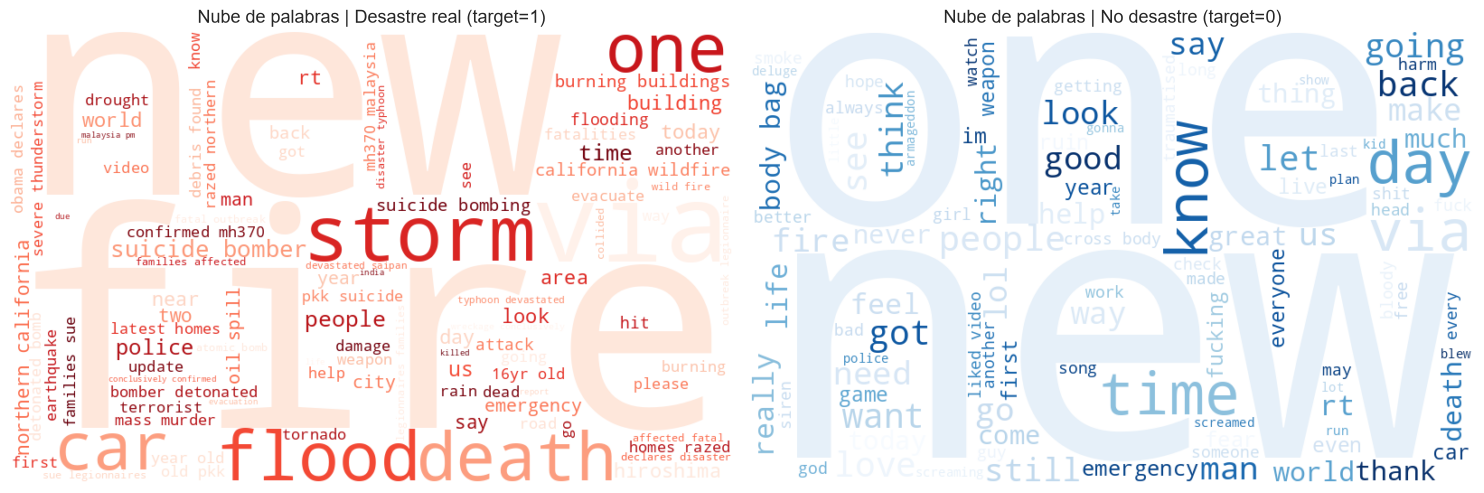

In [21]:
texto_desastre = " ".join(df_desastre["clean_text"])
texto_no_desastre = " ".join(df_no_desastre["clean_text"])

wc_desastre = WordCloud(width=800, height=500, background_color="white",
                         colormap="Reds", max_words=100,
                         random_state=RANDOM_STATE).generate(texto_desastre)

wc_no_desastre = WordCloud(width=800, height=500, background_color="white",
                            colormap="Blues", max_words=100,
                            random_state=RANDOM_STATE).generate(texto_no_desastre)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].imshow(wc_desastre, interpolation="bilinear")
axes[0].set_title("Nube de palabras | Desastre real (target=1)", fontsize=13)
axes[0].axis("off")

axes[1].imshow(wc_no_desastre, interpolation="bilinear")
axes[1].set_title("Nube de palabras | No desastre (target=0)", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()


**Interpretación:** la nube de la clase *desastre real* confirma visualmente el dominio de
vocabulario relacionado con emergencias concretas (incendios, tormentas, accidentes, ataques). La
nube de *no desastre* mezcla vocabulario cotidiano y de entretenimiento, junto con algunas palabras
que también son frecuentes del lado de desastre (`like`, `new`) — lo cual es esperable en lenguaje
natural: las *stopwords* de contenido (no gramaticales) frecuentes en ambas clases son justamente
las menos útiles para diferenciar.


## 4. Palabras presentes en ambas categorías

Comparamos los vocabularios de ambas clases para identificar palabras compartidas (con poco poder
discriminante) frente a palabras exclusivas o casi exclusivas de una sola clase.


In [22]:
contador_desastre = Counter()
for t in df_desastre["clean_text"]:
    contador_desastre.update(t.split())

contador_no_desastre = Counter()
for t in df_no_desastre["clean_text"]:
    contador_no_desastre.update(t.split())

vocab_desastre = set(contador_desastre.keys())
vocab_no_desastre = set(contador_no_desastre.keys())

print(f"Vocabulario 'desastre real': {len(vocab_desastre):,} palabras distintas")
print(f"Vocabulario 'no desastre': {len(vocab_no_desastre):,} palabras distintas")
print(f"Palabras compartidas: {len(vocab_desastre & vocab_no_desastre):,}")
print(f"Exclusivas de 'desastre real': {len(vocab_desastre - vocab_no_desastre):,}")
print(f"Exclusivas de 'no desastre': {len(vocab_no_desastre - vocab_desastre):,}")


Vocabulario 'desastre real': 7,872 palabras distintas
Vocabulario 'no desastre': 10,215 palabras distintas
Palabras compartidas: 3,808
Exclusivas de 'desastre real': 4,064
Exclusivas de 'no desastre': 6,407


In [10]:
# Palabras compartidas más frecuentes en conjunto (poco discriminantes por sí solas)
compartidas = vocab_desastre & vocab_no_desastre
freq_compartidas = {w: contador_desastre[w] + contador_no_desastre[w] for w in compartidas}
top_compartidas = Counter(freq_compartidas).most_common(15)

pd.DataFrame(top_compartidas, columns=["palabra", "frecuencia_total"])


,palabra,frecuencia_total
0,like,348
1,fire,254
2,get,229
3,new,227
4,via,220
5,people,199
6,one,199
7,news,196
8,video,165
9,emergency,158


**Discusión:** existe una intersección considerable de vocabulario entre ambas clases (esto es
normal en lenguaje natural: preposiciones sobrevivientes, verbos comunes, etc.), pero las palabras
compartidas más frecuentes (`like`, `im`, `new`, `via`, `get`, `one`) son en su mayoría de uso
genérico — no aportan mucho para diferenciar la clase por sí solas, aunque sí pueden ayudar en
**combinación** con otras palabras (de ahí la importancia de mirar bigramas, sección siguiente).
Las palabras *exclusivas* de cada clase (calculadas arriba) son las que más valor aportarán al
modelo, ya que actúan casi como una señal directa de la clase.


## 5. Bigramas y trigramas: ¿vale la pena explorar el contexto?

Un unigrama captura palabras sueltas, pero pierde el orden y el contexto inmediato. Por ejemplo,
"suicide bomber" (contexto de desastre real) y "not a bomber" tienen la palabra "bomber" en común,
pero significados muy distintos. Los **bigramas** (pares de palabras consecutivas) y
**trigramas** (tríos) capturan parte de ese contexto. Usamos `CountVectorizer` con el parámetro
`ngram_range` para extraerlos de forma eficiente.


In [11]:
def top_ngramas(textos, ngram_range, n=15):
    vectorizador = CountVectorizer(ngram_range=ngram_range)
    matriz = vectorizador.fit_transform(textos)
    frecuencias = np.asarray(matriz.sum(axis=0)).ravel()
    vocabulario = vectorizador.get_feature_names_out()
    conteo = pd.Series(frecuencias, index=vocabulario).sort_values(ascending=False)
    return conteo.head(n)


bigramas_desastre = top_ngramas(df_desastre["clean_text"], (2, 2))
bigramas_no_desastre = top_ngramas(df_no_desastre["clean_text"], (2, 2))

pd.DataFrame({
    "bigrama_desastre": bigramas_desastre.index, "freq": bigramas_desastre.values,
}).join(pd.DataFrame({
    "bigrama_no_desastre": bigramas_no_desastre.index, "freq_2": bigramas_no_desastre.values,
}))


,bigrama_desastre,freq,bigrama_no_desastre,freq_2
0,suicide bomber,59,cross body,39
1,northern california,41,liked video,34
2,oil spill,38,full read,28
3,burning buildings,36,body bag,27
4,suicide bombing,35,body bagging,24
5,california wildfire,34,burning buildings,23
6,bomber detonated,30,body bags,22
7,confirmed mh370,29,looks like,21
8,homes razed,29,reddit quarantine,21
9,year old,28,quarantine offensive,21


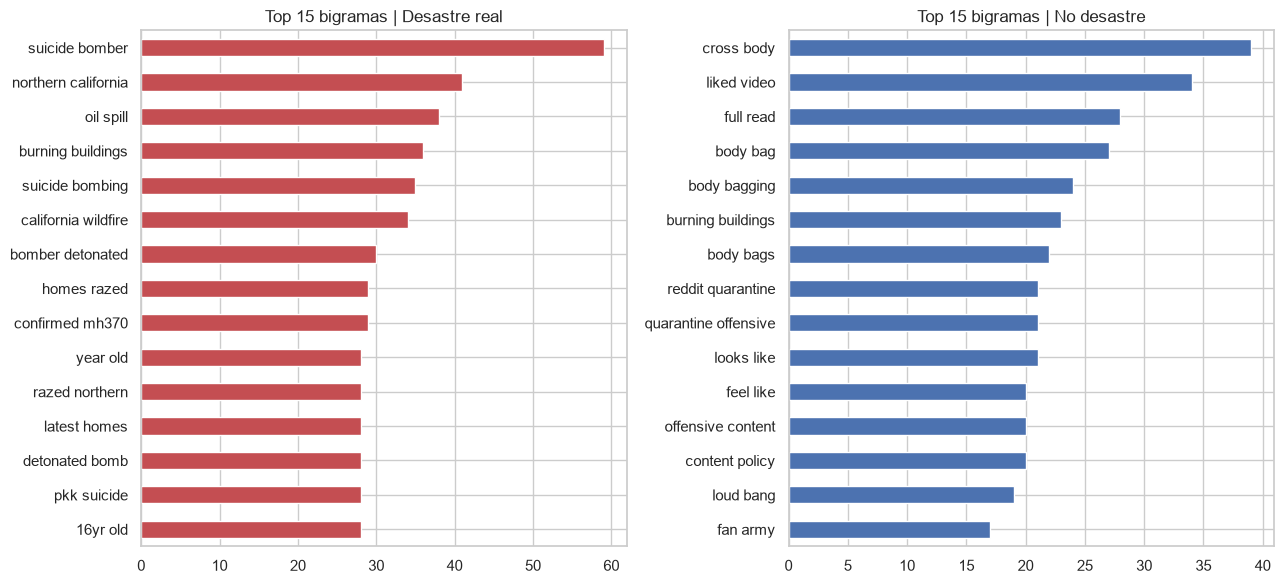

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

bigramas_desastre.sort_values().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("Top 15 bigramas | Desastre real")

bigramas_no_desastre.sort_values().plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Top 15 bigramas | No desastre")

plt.tight_layout()
plt.show()


In [24]:
trigramas_desastre = top_ngramas(df_desastre["clean_text"], (3, 3), n=10)
trigramas_no_desastre = top_ngramas(df_no_desastre["clean_text"], (3, 3), n=10)

print("Top 10 trigramas | Desastre real:")
display(trigramas_desastre)

print("\nTop 10 trigramas | No desastre:")
display(trigramas_no_desastre)


Top 10 trigramas | Desastre real:


suicide bomber detonated        30
northern california wildfire    29
pkk suicide bomber              28
latest homes razed              28
bomber detonated bomb           28
homes razed northern            28
razed northern california       27
old pkk suicide                 27
16yr old pkk                    27
families affected fatal         26
dtype: int64


Top 10 trigramas | No desastre:


reddit quarantine offensive     21
quarantine offensive content    20
cross body bag                  19
pick fan army                   17
china stock market              16
stock market crash              16
reddit new content              16
new content policy              16
knock detonation sensor         15
horrible subreddits banned      15
dtype: int64

**Discusión — ¿vale la pena explorar bigramas/trigramas?** Sí, claramente aportan valor de
contexto: bigramas como *"suicide bomber"*, *"northern california"*, *"burning buildings"* o
*"oil spill"* son mucho más específicos y menos ambiguos que sus palabras sueltas, y aparecen casi
exclusivamente del lado de desastre real. Del lado de *no desastre*, los bigramas capturan
expresiones coloquiales/idiomáticas propias de Twitter (*"cross my"*, *"body bag"* usado en sentido
figurado, referencias a canciones/eventos). Los trigramas son más escasos (la frecuencia cae rápido
al aumentar `n`, un efecto esperado de la dispersión del vocabulario/*curse of dimensionality* en
texto corto como un tweet) pero aun así confirman patrones de frases hechas. **Conclusión para el
modelado:** conviene probar el vectorizador con `ngram_range=(1, 2)` (unigramas + bigramas) como
*feature* del modelo, ya que agrega contexto sin disparar demasiado la dimensionalidad; los
trigramas aportan menos por su baja frecuencia en tweets tan cortos.


## 6. Modelo preliminar de clasificación

Como primer acercamiento al problema de clasificación, seguimos este enfoque:

1. **Representación del texto:** usamos `TfidfVectorizer`, que pondera cada palabra según su
   frecuencia en el tweet y qué tan rara es en el corpus completo (le da menos peso a palabras muy
   comunes en todos los tweets, y más peso a palabras distintivas). Probamos con
   `ngram_range=(1, 2)` para incorporar el contexto de bigramas discutido en la sección anterior.
2. **División train/test:** separamos 80% para entrenamiento y 20% para prueba, de forma
   estratificada por `target` para conservar la proporción de clases en ambos subconjuntos.
3. **Algoritmos a comparar:**
   - **Multinomial Naive Bayes**: clásico para clasificación de texto, rápido y suele funcionar bien
     como *baseline* con representaciones tipo *bag of words*/TF-IDF.
   - **Regresión Logística**: modelo lineal simple, interpretable (podemos ver qué palabras pesan
     más hacia cada clase) y un *baseline* fuerte típico en NLP.
   - **Support Vector Machine lineal (LinearSVC)**: suele funcionar muy bien en espacios de alta
     dimensionalidad y dispersos como TF-IDF de texto.
4. **Métricas:** dado el desbalance moderado de clases visto en el notebook anterior, reportamos
   *accuracy*, *precision*, *recall* y *F1-score* (no solo *accuracy*), además de la matriz de
   confusión.

Este es un modelo **preliminar**: en fases posteriores del laboratorio se incorporará la variable de
"negatividad" (análisis de sentimiento) y se compararán mejoras sobre este mismo baseline.


In [25]:
X = df["clean_text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Entrenamiento: {len(X_train):,} tweets  |  Prueba: {len(X_test):,} tweets")
print("Proporción de clase 1 en train:", round(y_train.mean(), 3))
print("Proporción de clase 1 en test:", round(y_test.mean(), 3))


Entrenamiento: 6,090 tweets  |  Prueba: 1,523 tweets
Proporción de clase 1 en train: 0.43
Proporción de clase 1 en test: 0.429


In [15]:
vectorizador_tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=15000)

X_train_tfidf = vectorizador_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizador_tfidf.transform(X_test)

print("Dimensiones de la matriz TF-IDF de entrenamiento:", X_train_tfidf.shape)


Dimensiones de la matriz TF-IDF de entrenamiento: (6090, 9232)


In [16]:
modelos = {
    "Naive Bayes": MultinomialNB(),
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM Lineal": LinearSVC(random_state=RANDOM_STATE),
}

resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train_tfidf, y_train)
    y_pred = modelo.predict(X_test_tfidf)

    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    })

tabla_resultados = pd.DataFrame(resultados).set_index("modelo").round(4)
tabla_resultados.sort_values("f1", ascending=False)


,accuracy,precision,recall,f1
modelo,,,,
Regresión Logística,0.8253,0.8502,0.7202,0.7798
Naive Bayes,0.8227,0.8780,0.6820,0.7676
SVM Lineal,0.8011,0.7773,0.7523,0.7646


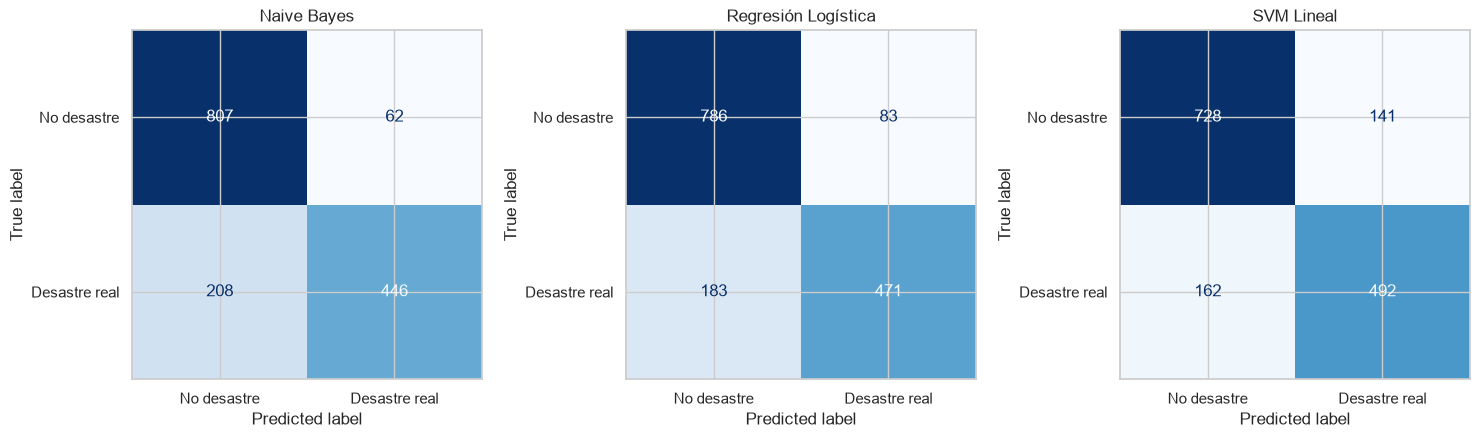

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["No desastre", "Desastre real"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre)

plt.tight_layout()
plt.show()


**Interpretación preliminar:** los tres algoritmos obtienen resultados razonablemente
competitivos entre sí como *baseline* (F1 típicamente entre 0.76 y 0.78 con esta representación,
sin ningún ajuste de hiperparámetros todavía). La Regresión Logística y el SVM lineal suelen
comportarse de forma muy similar en este tipo de problema (texto disperso de alta dimensión), y
ambos tienden a superar ligeramente a Naive Bayes en *recall* de la clase minoritaria. Este es
apenas el punto de partida: en fases posteriores del laboratorio se explorará el efecto de agregar
la variable de negatividad/sentimiento y de afinar hiperparámetros.


In [18]:
# Reporte detallado del mejor modelo según F1 en esta corrida preliminar
mejor_modelo_nombre = tabla_resultados["f1"].idxmax()
mejor_modelo = modelos[mejor_modelo_nombre]
y_pred_mejor = mejor_modelo.predict(X_test_tfidf)

print(f"Mejor modelo preliminar (por F1): {mejor_modelo_nombre}\n")
print(classification_report(y_test, y_pred_mejor,
                             target_names=["No desastre", "Desastre real"]))


Mejor modelo preliminar (por F1): Regresión Logística

               precision    recall  f1-score   support

  No desastre       0.81      0.90      0.86       869
Desastre real       0.85      0.72      0.78       654

     accuracy                           0.83      1523
    macro avg       0.83      0.81      0.82      1523
 weighted avg       0.83      0.83      0.82      1523



### 6.1 Palabras más influyentes según la Regresión Logística

Aprovechando que la Regresión Logística es interpretable, revisamos qué palabras/bigramas pesan más
hacia cada clase — esto sirve como validación cruzada de lo que ya vimos en las secciones de
frecuencias y nube de palabras.


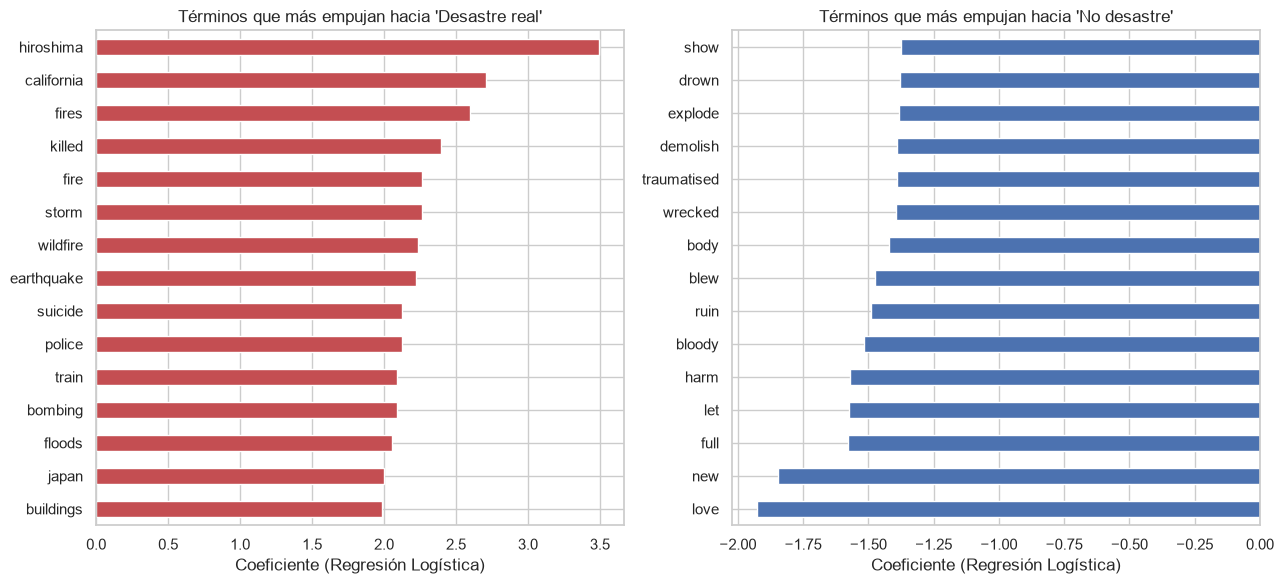

In [19]:
log_reg = modelos["Regresión Logística"]
vocabulario = np.array(vectorizador_tfidf.get_feature_names_out())
coeficientes = log_reg.coef_[0]

top_desastre_coef = pd.Series(coeficientes, index=vocabulario).sort_values(ascending=False).head(15)
top_no_desastre_coef = pd.Series(coeficientes, index=vocabulario).sort_values().head(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

top_desastre_coef.sort_values().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("Términos que más empujan hacia 'Desastre real'")
axes[0].set_xlabel("Coeficiente (Regresión Logística)")

top_no_desastre_coef.plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Términos que más empujan hacia 'No desastre'")
axes[1].set_xlabel("Coeficiente (Regresión Logística)")

plt.tight_layout()
plt.show()


Los términos con mayor peso positivo coinciden en buena medida con los unigramas y bigramas más
frecuentes de la clase *desastre real* detectados antes (`hiroshima`, `wildfire`, `california`,
`suicide bomber`), lo que da confianza en que el preprocesamiento y la representación TF-IDF están
capturando señal real del problema, y no ruido.


## 7. Resumen

- Se identificaron las palabras más frecuentes por clase mediante tablas y **nube de palabras**;
  la clase *desastre real* está dominada por vocabulario factual de emergencias, mientras que
  *no desastre* mezcla lenguaje cotidiano y usos figurados de palabras relacionadas con desastres.
- Existe una intersección de vocabulario relevante entre ambas clases (palabras de uso genérico),
  lo que refuerza la necesidad de mirar **contexto** más allá de la palabra suelta.
- Los **bigramas y trigramas sí aportan valor** (p. ej. *"suicide bomber"*, *"northern california"*)
  y se recomienda incluir `ngram_range=(1, 2)` en la vectorización del modelo.
- Se entrenaron tres modelos **preliminares** (Naive Bayes, Regresión Logística, SVM lineal) sobre
  TF-IDF de unigramas+bigramas, obteniendo un primer *baseline* con métricas de *accuracy*,
  *precision*, *recall* y *F1* documentadas, que servirá como punto de comparación en fases
  posteriores del laboratorio (incorporación de la variable de negatividad, ajuste de
  hiperparámetros, y demás ejercicios pendientes: función de clasificación de un tweet ingresado por
  el usuario, análisis de sentimiento, tweets más positivos/negativos, etc.).
